# MAL PRATICAL EVALUATION 2025

- Authors : Zakaria El Mrani & Malek Frikha
- Professeur : M. Mougeot

# Mise en Contexte

Nous disposons d’un jeu de données `celldata.csv` décrivant 8 000 clients d’un opérateur mobile. 
Chaque observation contient différentes informations sur les clients (données socio-démographiques 
et contractuelles) ainsi qu’une variable cible indiquant si le client a quitté l’opérateur 
(*churn*).

L’objectif de ce travail est :
1. de construire un modèle de prédiction du churn ;
2. de comparer plusieurs modèles de classification vus en cours selon différents critères 
   (performance, complexité, interprétabilité, etc.) ;
3. d’analyser la *fairness* des prédictions en considérant la caractéristique de genre (`Gender`) 
   comme attribut sensible.


# Exploration du Dataset

In [75]:
import pandas as pd
df = pd.read_csv('celldata.csv')
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,Salary,Churn
0,632,Germany,Female,50,5,107959.39,1,1,1,6985,1
1,649,France,Female,42,7,0.00,2,0,1,22974,0
2,595,France,Male,29,6,150685.79,1,1,0,87771,0
3,653,Spain,Male,35,6,116662.96,2,1,1,23864,0
4,559,Spain,Female,40,7,144470.77,1,1,1,18918,0


Nous possédons dans notre jeu de données 8 000 entrées correspondant à 8 000 clients, 
ainsi que 10 variables explicatives et une variable cible `Churn` :

- **CreditScore** : score de crédit du client, représentant la probabilité qu’il paie ses factures
  à temps. Plus le `CreditScore` est élevé, plus le client est considéré comme fiable.
- **Geography** : pays ou région de résidence du client (par exemple : France, Espagne, Allemagne).
- **Gender** : genre du client (`Male` / `Female`).
- **Age** : âge du client (en années).
- **Tenure** : ancienneté du client chez l’opérateur (en années).
- **Balance** : solde du compte du client auprès de l’opérateur (montant détenu).
- **NumOfProducts** : nombre de produits ou services souscrits par le client.
- **HasCrCard** : indicateur binaire valant 1 si le client possède une carte de crédit, 0 sinon.
- **IsActiveMember** : indicateur binaire valant 1 si le client est considéré comme “actif”, 0 sinon.
- **Salary** : estimation du revenu annuel du client.

- **Churn** : variable cible, valant 1 si le client a quitté l’opérateur (churn), 0 sinon.


In [76]:
df.describe(include="all")

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,Salary,Churn
count,8000.000000,8000,8000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
unique,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,4038,4373,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,650.805000,NaN,NaN,38.871625,5.013000,76011.635494,1.533625,0.704750,0.515750,100211.396750,0.201125
std,96.721648,NaN,NaN,10.446006,2.897565,62402.105212,0.583448,0.456184,0.499783,57165.688096,0.400866
min,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,12.000000,0.000000
25%,584.000000,NaN,NaN,32.000000,2.000000,0.000000,1.000000,0.000000,0.000000,51464.500000,0.000000
50%,652.000000,NaN,NaN,37.000000,5.000000,96846.565000,1.000000,1.000000,1.000000,100583.000000,0.000000
75%,718.000000,NaN,NaN,44.000000,7.000000,127593.625000,2.000000,1.000000,1.000000,149068.000000,0.000000


### Overview

- Le jeu de données ne contient aucune valeurs manquantes sur les 10 variables explicatives.
- Les variables catégorielles `Geography` et `Gender` présentent respectivement 3 et 2 modalités, avec une majorité de clients situés en France (environ 50 %) et une légère sur-représentation des hommes (~55 %).
- La variable cible `Churn` est déséquilibrée : environ 20 % des clients ont quitté l’opérateur, contre 80 % restés, ce qui doit être pris en compte dans l’évaluation des modèles.
- Les variables numériques présentent des ordres de grandeur variés : l’âge moyen est d’environ 39 ans, avec une distribution concentrée entre 30 et 45 ans, l’ancienneté (`Tenure`) est centrée autour de 5 ans, et le solde (`Balance`) montre une distribution très asymétrique avec au moins 25 % des clients ayant un solde nul. Enfin, environ 70 % des clients possèdent une carte de crédit et un peu plus de la moitié sont considérés comme membres actifs.

## PreProcessing

Afin de pouvoir utiliser nos modèles de manière efficace, nous devons encoder les variables
catégorielles. Comme ces variables représentent des catégories sans ordre naturel (par exemple
`Geography`, `Gender`), nous utilisons un encodage *one-hot* via `OneHotEncoder`.

Pour les variables numériques, nous appliquons une **standardisation**. Cela met toutes les variables sur une échelle comparable, ce qui est important pour les méthodes sensibles à l’échelle des features (par exemple KNN ou la régression logistique avec régularisation), et évite qu’une variable à grande variance domine les autres.

Nous allons donc distinguer deux types de prétraitement :
- un prétraitement avec **standardisation des variables numériques** (utile pour les modèles linéaires et KNN) ;
- un prétraitement sans standardisation (les arbres ne sont pas sensibles à l’échelle des variables).

Nous découpons ensuite le jeu de données en un ensemble d’entraînement et un ensemble de test,
afin d’ajuster les modèles sur les données d’entraînement et d’évaluer leurs performances sur
des données jamais vues.


In [77]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = df.drop(columns=["Churn"])
y = df["Churn"]

cat_cols = ["Geography", "Gender"]
num_cols = [c for c in X.columns if c not in cat_cols]

# Prétraitement avec standardisation (pour modèles linéaires + KNN-scaled)
preprocess_scaled = ColumnTransformer(
    transformers=[
("num", StandardScaler(), num_cols),
("cat", OneHotEncoder(drop="first"), cat_cols),
    ]
)

# Prétraitement sans standardisation des numériques (pour arbres, et KNN non-scalé)
preprocess_noscale = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(drop="first"), cat_cols),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Application des modèles

Dans cette section, nous comparons différentes familles de modèles vus en cours :

- **Baselines linéaires**
  - Régression logistique
  - LDA (Linear Discriminant Analysis)
  - QDA (Quadratic Discriminant Analysis)

- **Modèles à distance**
  - KNN sans mise à l’échelle des variables
  - KNN avec standardisation des variables

- **Arbres et méthodes d’ensemble**
  - Arbre de décision (CART)
  - Random Forest
  - Extra Trees
  - AdaBoost
  - Gradient Boosting

Pour chaque modèle, nous utilisons une validation croisée (CV) stratifiée à 5 folds sur l’ensemble 
d’apprentissage, et nous mesurons principalement l’**accuracy** et l’**AUC ROC**.

In [78]:
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

models = {
    "LogisticRegression": Pipeline([
        ("preprocess", preprocess_scaled),
        ("clf", LogisticRegression(max_iter=1000))
    ]),
    "LDA": Pipeline([
        ("preprocess", preprocess_scaled),
        ("clf", LinearDiscriminantAnalysis())
    ]),
    "QDA": Pipeline([
        ("preprocess", preprocess_scaled),
        ("clf", QuadraticDiscriminantAnalysis())
    ]),
    "KNN_no_scaling": Pipeline([
        ("preprocess", preprocess_noscale),
        ("clf", KNeighborsClassifier(n_neighbors=15))
    ]),
    "KNN_scaled": Pipeline([
        ("preprocess", preprocess_scaled),
        ("clf", KNeighborsClassifier(n_neighbors=15))
    ]),
    "DecisionTree": Pipeline([
        ("preprocess", preprocess_noscale),
        ("clf", DecisionTreeClassifier(random_state=0))
    ]),
    "RandomForest": Pipeline([
        ("preprocess", preprocess_noscale),
        ("clf", RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1))
    ]),
    "ExtraTrees": Pipeline([
        ("preprocess", preprocess_noscale),
        ("clf", ExtraTreesClassifier(n_estimators=200, random_state=0, n_jobs=-1))
    ]),
    "AdaBoost": Pipeline([
        ("preprocess", preprocess_noscale),
        ("clf", AdaBoostClassifier(n_estimators=200, random_state=0))
    ]),
    "GradientBoosting": Pipeline([
        ("preprocess", preprocess_noscale),
        ("clf", GradientBoostingClassifier(random_state=0))
    ]),
}

# Validation croisée sur l'ensemble d'entraînement

scoring = ["accuracy", "roc_auc"]
results = {}

for name, pipe in models.items():
    cv_res = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1, return_train_score=False)
    results[name] = {
        "acc_mean": cv_res["test_accuracy"].mean(),
        "acc_std": cv_res["test_accuracy"].std(),
        "auc_mean": cv_res["test_roc_auc"].mean(),
        "auc_std": cv_res["test_roc_auc"].std(),
    }


cv_df = pd.DataFrame(results).T
cv_df = cv_df.sort_values("auc_mean", ascending=False)
cv_df



,acc_mean,acc_std,auc_mean,auc_std
GradientBoosting,0.865500,0.004815,0.865301,0.006438
RandomForest,0.861250,0.004627,0.854231,0.010464
ExtraTrees,0.855125,0.006930,0.847022,0.011310
AdaBoost,0.854625,0.004586,0.842842,0.012163
KNN_scaled,0.846125,0.003566,0.822067,0.008596
QDA,0.833250,0.006379,0.809786,0.014271
LDA,0.809500,0.002512,0.758675,0.017501
LogisticRegression,0.812250,0.003368,0.756281,0.017708
DecisionTree,0.799750,0.003593,0.694934,0.010555
KNN_no_scaling,0.794000,0.002839,0.534757,0.009035


### Résultats de la validation croisée

Nous avons évalué plusieurs modèles de classification au moyen d’une validation croisée 
stratifiée à 5 folds, en mesurant l’accuracy et surtout l’AUC ROC (plus appropriée ici car 
la classe "churn" est minoritaire, ~20 % des observations).

- Les meilleures performances sont obtenues par les méthodes d’ensemble basées sur des arbres
  de décision :
  - **GradientBoostingClassifier** : AUC moyenne ≈ 0.865, accuracy ≈ 0.866 ;
  - **RandomForestClassifier** : AUC ≈ 0.854 ;
  - **ExtraTreesClassifier** : AUC ≈ 0.847.
  
  Ces méthodes capturent bien les non-linéarités et les interactions entre variables, tout en 
  contrôlant le biais et la variance grâce à l’agrégation d’arbres faibles.

- Les modèles linéaires (régression logistique, LDA, QDA) offrent des performances correctes 
  (AUC entre 0.75 et 0.81) et constituent de bonnes **baselines interprétables**, mais ils restent 
  en retrait par rapport aux ensembles d’arbres sur ce jeu de données.

- Le KNN illustre bien l’impact du prétraitement :
  - sans standardisation des variables (`KNN_no_scaling`), l’AUC tombe à ~0.53 (proche d’un 
    classifieur aléatoire) ;
  - après standardisation (`KNN_scaled`), l’AUC remonte à ~0.82.
  
- Enfin, l’arbre de décision seul (DecisionTreeClassifier) obtient une AUC plus faible (~0.69), 
  ce qui traduit une forte variance et une tendance à l’overfitting. C’est précisément ce que les 
  méthodes d’ensemble (Random Forest, Gradient Boosting, etc.) cherchent à corriger.

### Choix du modèle conseillé

Au vu des résultats, **GradientBoosting** apparaît comme le meilleur compromis entre 
performance et stabilité : il obtient la plus grande AUC moyenne (~0.865) avec une faible variance 
entre les folds. Nous le retiendrons donc comme **modèle principal de prédiction du churn** pour 
la suite du projet.

# Fairness

On étudie maintenant la fairness en considérant :

- `Y` : Churn
- `S` : Gender (Male / Female)
- `F` : score de churn (probabilité prédite) ou prédiction binaire

Les trois critères de fairness étant :

Independence : F⊥S
→ Le taux de décisions positives doit être le même dans chaque groupe.

Separation : F⊥S∣Y
→ Pour chaque vrai label, la distribution des prédictions ne doit pas dépendre de S.
En pratique : égalité des TPR et des FPR entre groupes.

Sufficiency : Y⊥S∣F
→ À score égal, le risque réel doit être le même pour tous les groupes.

On ne peut pas satisfaire simultanément deux de ces critères dès lors que Y et S sont corrélés et que le modèle est non trivial, or c'est le cas ici (taux de churn différents entre hommes et femmes).

### Fit du modèle & prédictions

Test AUC: 0.8688945265797684
Test ACC: 0.8725


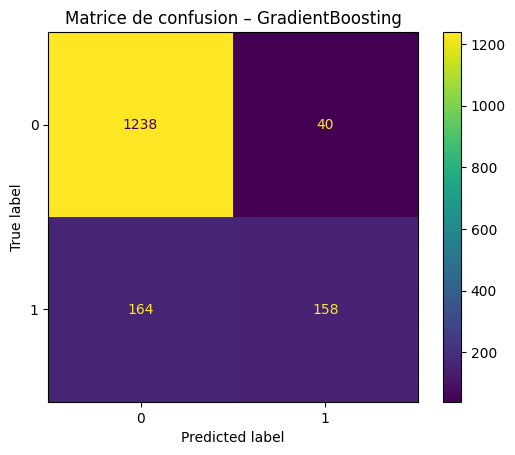

In [79]:
from sklearn.metrics import roc_auc_score

gb = Pipeline(steps=[
    ("preprocess", preprocess_scaled),
    ("clf", GradientBoostingClassifier(random_state=0))
])

gb.fit(X_train, y_train)

proba_test = gb.predict_proba(X_test)[:, 1]
y_pred = (proba_test >= 0.5).astype(int)

overall_auc = roc_auc_score(y_test, proba_test)
overall_acc = (y_pred == y_test).mean()
print("Test AUC:", overall_auc)
print("Test ACC:", overall_acc)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Matrice de confusion – GradientBoosting")
plt.show()



In [80]:
test = X_test.copy()
test["y_true"] = y_test
test["y_pred"] = y_pred
test["score"] = proba_test

### Independence
On regarde le taux de prédictions positives par genre :

Gender
Female    0.156889
Male      0.095732
Name: y_pred, dtype: float64


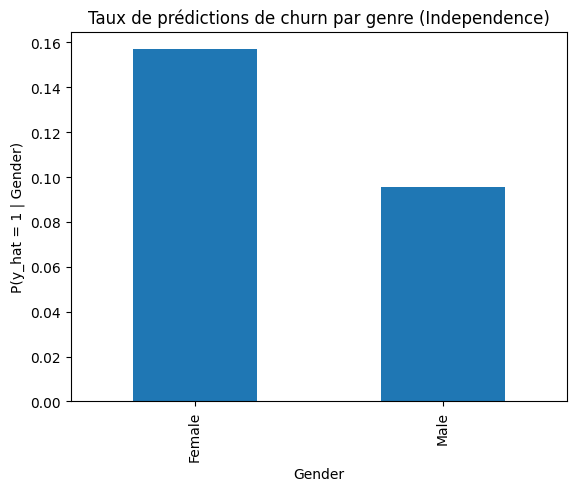

In [81]:
pos_rate_by_gender = test.groupby("Gender")["y_pred"].mean()
print(pos_rate_by_gender)

plt.figure()
pos_rate_by_gender.plot(kind="bar")
plt.ylabel("P(y_hat = 1 | Gender)")
plt.title("Taux de prédictions de churn par genre (Independence)")
plt.show()

Les femmes reçoivent plus souvent une prédiction de churn que les hommes.

Independence est clairement violé : les distributions de F ne sont pas identiques entre genres. On a donc pas de parité demographique.

Ce n’est pas surprenant car le taux de churn réel est lui-même plus élevé chez les femmes dans les données brutes.

### Séparation

On calcule TPR et FPR par genre

             TPR       FPR
Gender                    
Female  0.508021  0.036630
Male    0.466667  0.027322


/tmp/ipykernel_266600/1901021783.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sep = test.groupby("Gender").apply(group_stats)


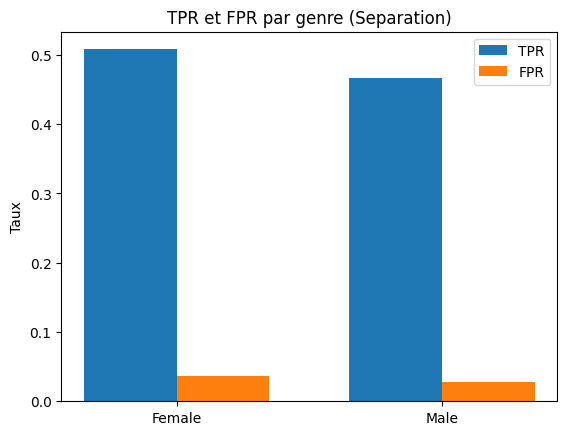

In [82]:
import numpy as np

def group_stats(group):
    y_true = group["y_true"].values
    y_pred = group["y_pred"].values
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    return pd.Series({"TPR": tpr, "FPR": fpr})

sep = test.groupby("Gender").apply(group_stats)
print(sep)

plt.figure()
x = np.arange(len(sep))
width = 0.35
plt.bar(x - width/2, sep["TPR"], width, label="TPR")
plt.bar(x + width/2, sep["FPR"], width, label="FPR")
plt.xticks(x, sep.index)
plt.ylabel("Taux")
plt.title("TPR et FPR par genre (Separation)")
plt.legend()
plt.show()


Les femmes ont à la fois un TPR légèrement plus élevé (le modèle détecte un peu mieux les churners femmes) et une FPR plus élevée (plus de faux positifs femmes).

Les TPR/FPR ne sont pas identiques donc le critère de Séparation n'est pas satisfaite.

L’Equality of Opportunity (égalité des TPR uniquement) est “pas trop mal” mais pas parfaite.

### Sufficiency

Pour vérifier ce critère, on va comparer, pour un même niveau de score (F), la probabilité réelle de churn entre hommes et femmes.
En pratique, on ne peut pas regarder chaque valeur exacte du score, donc on découpe l’axe des scores en quelques tranches.

On choisit `q = 5` dans `pd.qcut` pour obtenir 5 intervalles contenant chacun à peu près le même nombre d’observations.
* avec trop peu de tranches, on n’a qu’une moyenne globale et on ne voit pas ce qui se passe pour les faibles / forts scores
* avec trop de tranches, on se retrouve avec très peu d’individus par intervalle et les taux de churn deviennent très bruités.

`q = 5` est donc un bon compromis

In [83]:
test["score_bin"] = pd.qcut(test["score"], q=5, duplicates="drop")

calib = (test.groupby(["Gender", "score_bin"]).agg(mean_score=("score", "mean"), rate=("y_true", "mean"),n=("y_true", "size")).reset_index())

print(calib)


/tmp/ipykernel_266600/2900227434.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calib = (test.groupby(["Gender", "score_bin"]).agg(mean_score=("score", "mean"), rate=("y_true", "mean"),n=("y_true", "size")).reset_index())


   Gender                       score_bin  mean_score      rate    n
0  Female  (0.012199999999999999, 0.0387]    0.028234  0.046729  107
1  Female                (0.0387, 0.0797]    0.058589  0.046875  128
2  Female                 (0.0797, 0.145]    0.111206  0.136054  147
3  Female                    (0.145, 0.3]    0.208931  0.220238  168
4  Female                    (0.3, 0.995]    0.620804  0.650273  183
5    Male  (0.012199999999999999, 0.0387]    0.023710  0.004695  213
6    Male                (0.0387, 0.0797]    0.056731  0.031250  192
7    Male                 (0.0797, 0.145]    0.105362  0.098266  173
8    Male                    (0.145, 0.3]    0.203302  0.164474  152
9    Male                    (0.3, 0.995]    0.608288  0.627737  137



* Pour les **scores élevés** (`(0.3, 0.995]`), la calibration est bonne et assez proche entre genres :

  * Femmes : score moyen ≈ 0.62, taux réel ≈ 0.65
  * Hommes : score moyen ≈ 0.61, taux réel ≈ 0.63
    → À fort risque, le score a à peu près la même signification pour les deux genres.

* Pour les **scores moyens** (`(0.0797, 0.145]` et `(0.145, 0.3]`), les différences restent modérées :

  * Les écarts entre `mean_score` et `rate` sont raisonnables pour les deux genres.
  * Pour `Female` dans `(0.0797, 0.145]`, le modèle sous-estime un peu le churn (0.11 vs 0.136), alors que pour `Male` il est bien aligné (0.105 vs 0.098).

* Pour les **scores faibles**, la calibration par genre est beaucoup moins bonne :

  * Bin `(0.0122, 0.0387]` :

    * Femmes : score ≈ 2.8 %, churn réel ≈ 4.7 %
    * Hommes : score ≈ 2.4 %, churn réel ≈ 0.5 %
      → À score très faible, les femmes churnent plus souvent que ce que le modèle prédit, et les hommes beaucoup moins.
  * Bin `(0.0387, 0.0797]` :

    * Femmes : 5.9 % vs 4.7 %
    * Hommes : 5.7 % vs 3.1 %
      → le modèle surestime le risque pour les deux genres, mais davantage pour les hommes.

Globalement, le modèle est **raisonnablement calibré et assez proche de la sufficiency pour les scores moyens à élevés**, où un même score correspond à un risque réel de churn similaire pour les deux genres.

## Conclusion sur la fairness du modèle

Le modèle présente de bonnes performances globales et une calibration raisonnable, mais
il ne satisfait pas les critères d’Independence et de Separation, et la Sufficiency n’est que
partiellement vérifiée. Ces résultats sont cohérents avec la structure des données (taux de churn
différents selon le genre) et illustrent le compromis inévitable entre performance prédictive et
fairness au sens des différentes définitions étudiées en cours.